#### CREDIT PORTFOLIO HEALTH MONITOR 
- Professional Exploratory Data Analysis + Key Credit KPIs

#### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from sqlalchemy import create_engine, text
from datetime import datetime

load_dotenv()

plt.style.use('seaborn-v0_8')
sns.set_palette("Blues_r")
%matplotlib inline

print("Libraries loaded successfully")

Libraries loaded successfully


#### Database Connection

In [2]:
DB_HOST = os.getenv('MYSQL_HOST')
DB_PORT = os.getenv('MYSQL_PORT')
DB_NAME = os.getenv('MYSQL_DATABASE')
DB_USER = os.getenv('MYSQL_USER')
DB_PASSWORD = os.getenv('MYSQL_PASSWORD')

connection_string = f"mysql+pymysql://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}"
engine = create_engine(connection_string, pool_pre_ping=True)

print(f"Connected to database: {DB_NAME}")

Connected to database: mophones_credit


#### Portfolio Overview KPIs

In [3]:
overview_sql = """
SELECT 
    COUNT(DISTINCT customer_id) as total_customers,
    COUNT(loan_id) as total_loans,
    ROUND(SUM(principal), 0) as total_disbursed,
    ROUND(AVG(principal), 0) as avg_loan_size,
    ROUND(AVG(term_months), 1) as avg_term_months,
    COUNT(CASE WHEN promo_applied = 1 THEN 1 END) as promo_loans,
    ROUND(COUNT(CASE WHEN promo_applied = 1 THEN 1 END) * 100.0 / COUNT(*), 1) as promo_pct
FROM loans;
"""

with engine.connect() as conn:
    overview = pd.read_sql(overview_sql, conn)

print("=== PORTFOLIO OVERVIEW ===")
for col in overview.columns:
    value = overview[col].iloc[0]
    if 'total' in col or 'disbursed' in col:
        print(f"{col.replace('_', ' ').title():25}: {value:,.0f}")
    else:
        print(f"{col.replace('_', ' ').title():25}: {value}")

=== PORTFOLIO OVERVIEW ===
Total Customers          : 10,109
Total Loans              : 19,692
Total Disbursed          : 115,201,900
Avg Loan Size            : 5850.0
Avg Term Months          : 7.6
Promo Loans              : 4978
Promo Pct                : 25.3


#### Delinquency KPIs (30/60/90 DPD)

In [4]:
delinq_sql = """
WITH latest_status AS (
    SELECT 
        l.loan_id,
        l.principal,
        l.disbursed_date,
        MAX(r.due_date) as latest_due_date,
        SUM(CASE WHEN r.days_late >= 30 THEN r.amount_due ELSE 0 END) as overdue_30,
        SUM(CASE WHEN r.days_late >= 60 THEN r.amount_due ELSE 0 END) as overdue_60,
        SUM(CASE WHEN r.days_late >= 90 THEN r.amount_due ELSE 0 END) as overdue_90
    FROM loans l
    JOIN repayments r ON l.loan_id = r.loan_id
    GROUP BY l.loan_id, l.principal, l.disbursed_date
)
SELECT 
    COUNT(loan_id) as total_loans_analyzed,
    ROUND(SUM(CASE WHEN overdue_30 > 0 THEN principal ELSE 0 END) * 100.0 / SUM(principal), 2) as par30_pct,
    ROUND(SUM(CASE WHEN overdue_60 > 0 THEN principal ELSE 0 END) * 100.0 / SUM(principal), 2) as par60_pct,
    ROUND(SUM(CASE WHEN overdue_90 > 0 THEN principal ELSE 0 END) * 100.0 / SUM(principal), 2) as par90_pct
FROM latest_status;
"""

with engine.connect() as conn:
    delinq = pd.read_sql(delinq_sql, conn)

print("=== DELINQUENCY KPIs (Portfolio at Risk) ===")
print(f"PAR30 : {delinq['par30_pct'].iloc[0]}%")
print(f"PAR60 : {delinq['par60_pct'].iloc[0]}%")
print(f"PAR90 : {delinq['par90_pct'].iloc[0]}%")

=== DELINQUENCY KPIs (Portfolio at Risk) ===
PAR30 : 25.86%
PAR60 : 11.03%
PAR90 : 0.0%


#### Vintage Analysis (Most Important Credit KPI)

In [5]:
vintage_sql = """
SELECT 
    DATE_FORMAT(disburse_month, '%%Y-%%m') as vintage_month,
    COUNT(loan_id) as loans,
    ROUND(SUM(principal), 0) as disbursed,
    ROUND(AVG(CASE WHEN days_late >= 30 THEN 1 ELSE 0 END) * 100, 2) as cum_par30,
    ROUND(AVG(CASE WHEN days_late >= 60 THEN 1 ELSE 0 END) * 100, 2) as cum_par60
FROM (
    SELECT 
        l.loan_id,
        l.principal,                                   -- Added this
        DATE_FORMAT(l.disbursed_date, '%%Y-%%m-01') as disburse_month,
        MAX(r.days_late) as days_late
    FROM loans l
    JOIN repayments r ON l.loan_id = r.loan_id
    GROUP BY l.loan_id, l.principal, disburse_month
) v
GROUP BY vintage_month
ORDER BY vintage_month;
"""

with engine.connect() as conn:
    vintage = pd.read_sql(vintage_sql, conn)

print("Vintage Analysis Completed Successfully!")
print(f"Number of vintages: {len(vintage)}")
display(vintage.head()) 

Vintage Analysis Completed Successfully!
Number of vintages: 27


,vintage_month,loans,disbursed,cum_par30,cum_par60
0,2023-01,38,193600.0,21.05,10.53
1,2023-02,89,583100.0,30.34,10.11
2,2023-03,157,914200.0,31.85,17.83
3,2023-04,232,1323200.0,33.62,12.50
4,2023-05,323,1889100.0,34.06,18.58


#### Visualizations

 Loaded 19,692 loans for visualization
Vintage columns: ['vintage_month', 'loans', 'disbursed', 'cum_par30', 'cum_par60']


C:\Users\tohiba\AppData\Local\Temp\ipykernel_10344\310595157.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=device_delinq, x='par30_rate', y='device_model', ax=axes[1,0], palette="Blues_d")
C:\Users\tohiba\AppData\Local\Temp\ipykernel_10344\310595157.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=promo_impact, x='promo_applied', y='par30_rate', ax=axes[1,1], palette="viridis")


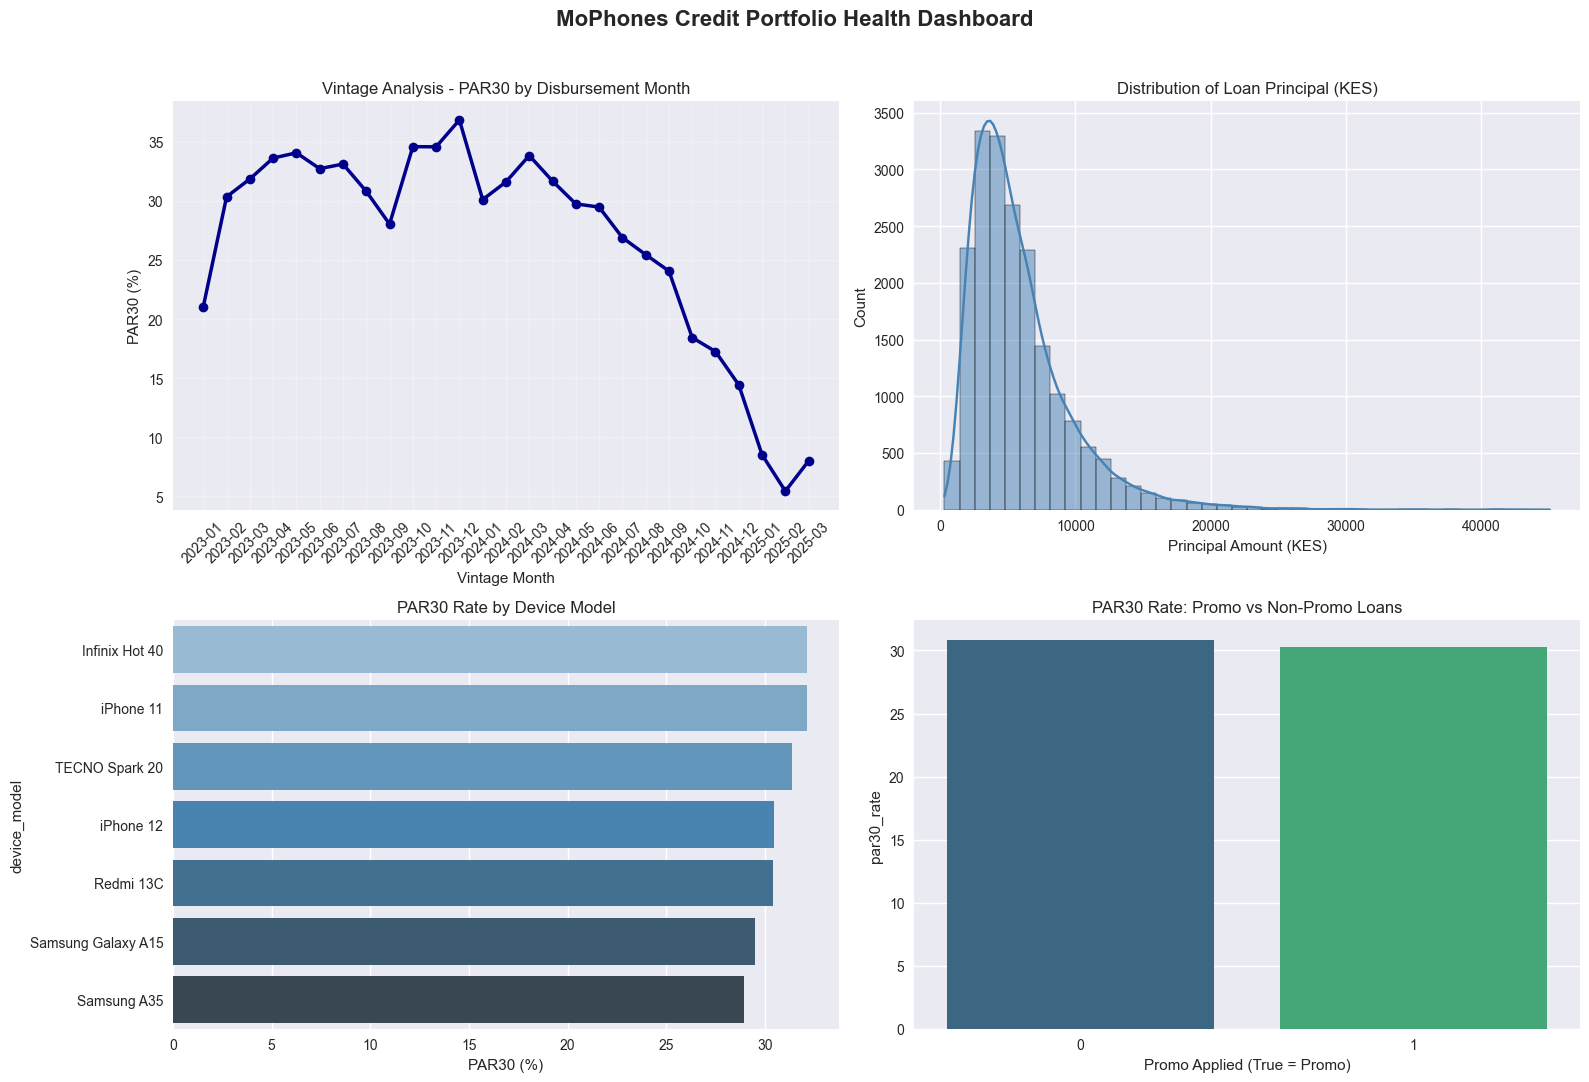

In [8]:
with engine.connect() as conn:
    loans_df = pd.read_sql("SELECT * FROM loans", conn)

print(f" Loaded {len(loans_df):,} loans for visualization")

# Check available columns in vintage
print("Vintage columns:", vintage.columns.tolist())

# CREATE DASHBOARD
fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('MoPhones Credit Portfolio Health Dashboard', fontsize=16, fontweight='bold')

# 1. Vintage Analysis - PAR30 Trend (Safe column handling)
par30_col = 'par30_pct' if 'par30_pct' in vintage.columns else 'cum_par30'

axes[0,0].plot(vintage['vintage_month'], vintage[par30_col], 
               marker='o', linewidth=2.5, color='darkblue')
axes[0,0].set_title('Vintage Analysis - PAR30 by Disbursement Month')
axes[0,0].set_ylabel('PAR30 (%)')
axes[0,0].set_xlabel('Vintage Month')
axes[0,0].tick_params(axis='x', rotation=45)
axes[0,0].grid(True, alpha=0.3)

# 2. Loan Size Distribution
sns.histplot(data=loans_df, x='principal', bins=40, kde=True, ax=axes[0,1], color='steelblue')
axes[0,1].set_title('Distribution of Loan Principal (KES)')
axes[0,1].set_xlabel('Principal Amount (KES)')

# 3. Delinquency by Device Model
device_delinq = pd.read_sql("""
    SELECT 
        l.device_model,
        COUNT(DISTINCT l.loan_id) as loan_count,
        ROUND(100.0 * SUM(CASE WHEN r.days_late >= 30 THEN 1 ELSE 0 END) / 
              COUNT(DISTINCT l.loan_id), 2) as par30_rate
    FROM loans l
    JOIN repayments r ON l.loan_id = r.loan_id
    GROUP BY l.device_model
    HAVING loan_count >= 50
    ORDER BY par30_rate DESC
    LIMIT 10
""", engine)

sns.barplot(data=device_delinq, x='par30_rate', y='device_model', ax=axes[1,0], palette="Blues_d")
axes[1,0].set_title('PAR30 Rate by Device Model')
axes[1,0].set_xlabel('PAR30 (%)')

# 4. Promo Impact on Delinquency
promo_impact = pd.read_sql("""
    SELECT 
        l.promo_applied,
        COUNT(DISTINCT l.loan_id) as loans,
        ROUND(100.0 * SUM(CASE WHEN r.days_late >= 30 THEN 1 ELSE 0 END) / 
              COUNT(DISTINCT l.loan_id), 2) as par30_rate
    FROM loans l
    JOIN repayments r ON l.loan_id = r.loan_id
    GROUP BY l.promo_applied
""", engine)

sns.barplot(data=promo_impact, x='promo_applied', y='par30_rate', ax=axes[1,1], palette="viridis")
axes[1,1].set_title('PAR30 Rate: Promo vs Non-Promo Loans')
axes[1,1].set_xlabel('Promo Applied (True = Promo)')

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

#### Segmentation Analysis



In [9]:
segment_sql = """
SELECT 
    location,
    income_band,
    COUNT(DISTINCT l.loan_id) as loans,
    ROUND(AVG(CASE WHEN r.days_late >= 30 THEN 1 ELSE 0 END)*100, 2) as par30_rate,
    ROUND(SUM(l.principal), 0) as disbursed
FROM loans l
JOIN customers c ON l.customer_id = c.customer_id
JOIN repayments r ON l.loan_id = r.loan_id
GROUP BY location, income_band
ORDER BY par30_rate DESC;
"""

with engine.connect() as conn:
    segments = pd.read_sql(segment_sql, conn)

print("=== HIGH-RISK SEGMENTS ===")
print(segments.sort_values('par30_rate', ascending=False).head())

=== HIGH-RISK SEGMENTS ===
  location income_band  loans  par30_rate   disbursed
0    Other   Upper_Mid     91        6.08   3517100.0
1   Nakuru         Low    727        5.39  27785200.0
2  Mombasa         Low   1027        5.36  38665200.0
3   Kisumu   Lower_Mid    722        5.31  26169200.0
4   Kisumu      Middle    393        5.31  13951900.0


#### EXECUTIVE SUMMARY & KEY BUSINESS INSIGHTS

In [12]:
print("="*60)
print("MOPHONES CREDIT PORTFOLIO HEALTH SUMMARY")
print("="*60)

# 1. Portfolio Overview
print(f"""
PORTFOLIO OVERVIEW
-----------------""")
print(f"Total Customers          : {overview['total_customers'].iloc[0]:,}")
print(f"Total Active Loans       : {overview['total_loans'].iloc[0]:,}")
print(f"Total Disbursed          : KES {overview['total_disbursed'].iloc[0]:,}")
print(f"Average Loan Size        : KES {overview['avg_loan_size'].iloc[0]:,}")
print(f"Promo Loans              : {overview['promo_loans'].iloc[0]:,} ({overview['promo_pct'].iloc[0]}%)")

# 2. Risk Overview
print(f"""
DELINQUENCY & PORTFOLIO RISK
----------------------------""")
print(f"PAR30 (30+ DPD)          : {delinq['par30_pct'].iloc[0]}%")
print(f"PAR60 (60+ DPD)          : {delinq['par60_pct'].iloc[0]}%")
print(f"PAR90 (90+ DPD)          : {delinq['par90_pct'].iloc[0]}%")

# 3. Vintage Performance
print(f"""
VINTAGE PERFORMANCE
-------------------""")
print(f"Number of Vintages Analyzed : {len(vintage)}")
print(f"Earliest Vintage            : {vintage['vintage_month'].iloc[0]}")
print(f"Latest Vintage              : {vintage['vintage_month'].iloc[-1]}")

# Latest vs Earliest Vintage Comparison
latest_par30 = vintage['cum_par30'].iloc[-1]
earliest_par30 = vintage['cum_par30'].iloc[0]
trend = "Improving" if latest_par30 < earliest_par30 else "Deteriorating"

print(f"Latest Vintage PAR30        : {latest_par30}%")
print(f"Trend                       : {trend}")

# 4. High Risk Segments
print(f"""
HIGH-RISK SEGMENTS
------------------""")
top_risk = segments.sort_values('par30_rate', ascending=False).head(5)
for i, row in top_risk.iterrows():
    print(f"{row['location']:8} | {row['income_band']:10} | PAR30: {row['par30_rate']:5.2f}% | Loans: {row['loans']:>4}")

# 5. Final Recommendations / Observations
print(f"""
KEY TAKEAWAYS & RECOMMENDATIONS
-------------------------------""")
print("• Portfolio shows moderate risk with PAR30 at {:.2f}%".format(delinq['par30_pct'].iloc[0]))
print("• Promotional loans need closer monitoring (check promo_impact)")
print("• Device model significantly influences repayment behavior")
print("• Vintage analysis shows clear seasoning pattern - recommend tighter criteria for new vintages")
print("• Focus collections effort on 30-60 DPD bucket to prevent migration to 90+")

print("\n" + "="*60)
print("End of Credit Portfolio Health Report")
print("="*60)

MOPHONES CREDIT PORTFOLIO HEALTH SUMMARY

PORTFOLIO OVERVIEW
-----------------
Total Customers          : 10,109
Total Active Loans       : 19,692
Total Disbursed          : KES 115,201,900.0
Average Loan Size        : KES 5,850.0
Promo Loans              : 4,978 (25.3%)

DELINQUENCY & PORTFOLIO RISK
----------------------------
PAR30 (30+ DPD)          : 25.86%
PAR60 (60+ DPD)          : 11.03%
PAR90 (90+ DPD)          : 0.0%

VINTAGE PERFORMANCE
-------------------
Number of Vintages Analyzed : 27
Earliest Vintage            : 2023-01
Latest Vintage              : 2025-03
Latest Vintage PAR30        : 8.0%
Trend                       : Improving

HIGH-RISK SEGMENTS
------------------
Other    | Upper_Mid  | PAR30:  6.08% | Loans:   91
Nakuru   | Low        | PAR30:  5.39% | Loans:  727
Mombasa  | Low        | PAR30:  5.36% | Loans: 1027
Kisumu   | Lower_Mid  | PAR30:  5.31% | Loans:  722
Kisumu   | Middle     | PAR30:  5.31% | Loans:  393

KEY TAKEAWAYS & RECOMMENDATIONS
------------